In [28]:
import matplotlib.pyplot as plt
import numpy as np

In [29]:
labels = ['processors','local list sz', 'time']
D = np.array([
    [1, 20480000, 2.263726],
    [1, 40960000, 4.691691],
    [2, 20480000, 2.337111],
    [1, 81920000, 9.607471],
    [4, 20480000, 2.413035],
    [1, 163840000, 19.859764],
    [8, 20480000, 2.526783],
    [1, 327680000, 40.656566],
    [16, 20480000, 2.879517],
    [1, 655360000, 83.356357],
    [32, 20480000, 3.120093],
    [1, 1310720000, 171.086431],
    [64, 20480000, 3.455093]
])
print(D)

O = np.array([
    [1, 20480000, 2.063854],
    [2, 10240000, 1.040676],
    [4, 5120000, 0.548521],
    [8, 2560000, 0.281344],
    [16, 1280000, 0.401803],
    [32, 640000, 0.611809],
    [64, 320000, 0.062534],
])
print(O)

[[1.00000000e+00 2.04800000e+07 2.26372600e+00]
 [1.00000000e+00 4.09600000e+07 4.69169100e+00]
 [2.00000000e+00 2.04800000e+07 2.33711100e+00]
 [1.00000000e+00 8.19200000e+07 9.60747100e+00]
 [4.00000000e+00 2.04800000e+07 2.41303500e+00]
 [1.00000000e+00 1.63840000e+08 1.98597640e+01]
 [8.00000000e+00 2.04800000e+07 2.52678300e+00]
 [1.00000000e+00 3.27680000e+08 4.06565660e+01]
 [1.60000000e+01 2.04800000e+07 2.87951700e+00]
 [1.00000000e+00 6.55360000e+08 8.33563570e+01]
 [3.20000000e+01 2.04800000e+07 3.12009300e+00]
 [1.00000000e+00 1.31072000e+09 1.71086431e+02]
 [6.40000000e+01 2.04800000e+07 3.45509300e+00]]
[[1.000000e+00 2.048000e+07 2.063854e+00]
 [2.000000e+00 1.024000e+07 1.040676e+00]
 [4.000000e+00 5.120000e+06 5.485210e-01]
 [8.000000e+00 2.560000e+06 2.813440e-01]
 [1.600000e+01 1.280000e+06 4.018030e-01]
 [3.200000e+01 6.400000e+05 6.118090e-01]
 [6.400000e+01 3.200000e+05 6.253400e-02]]


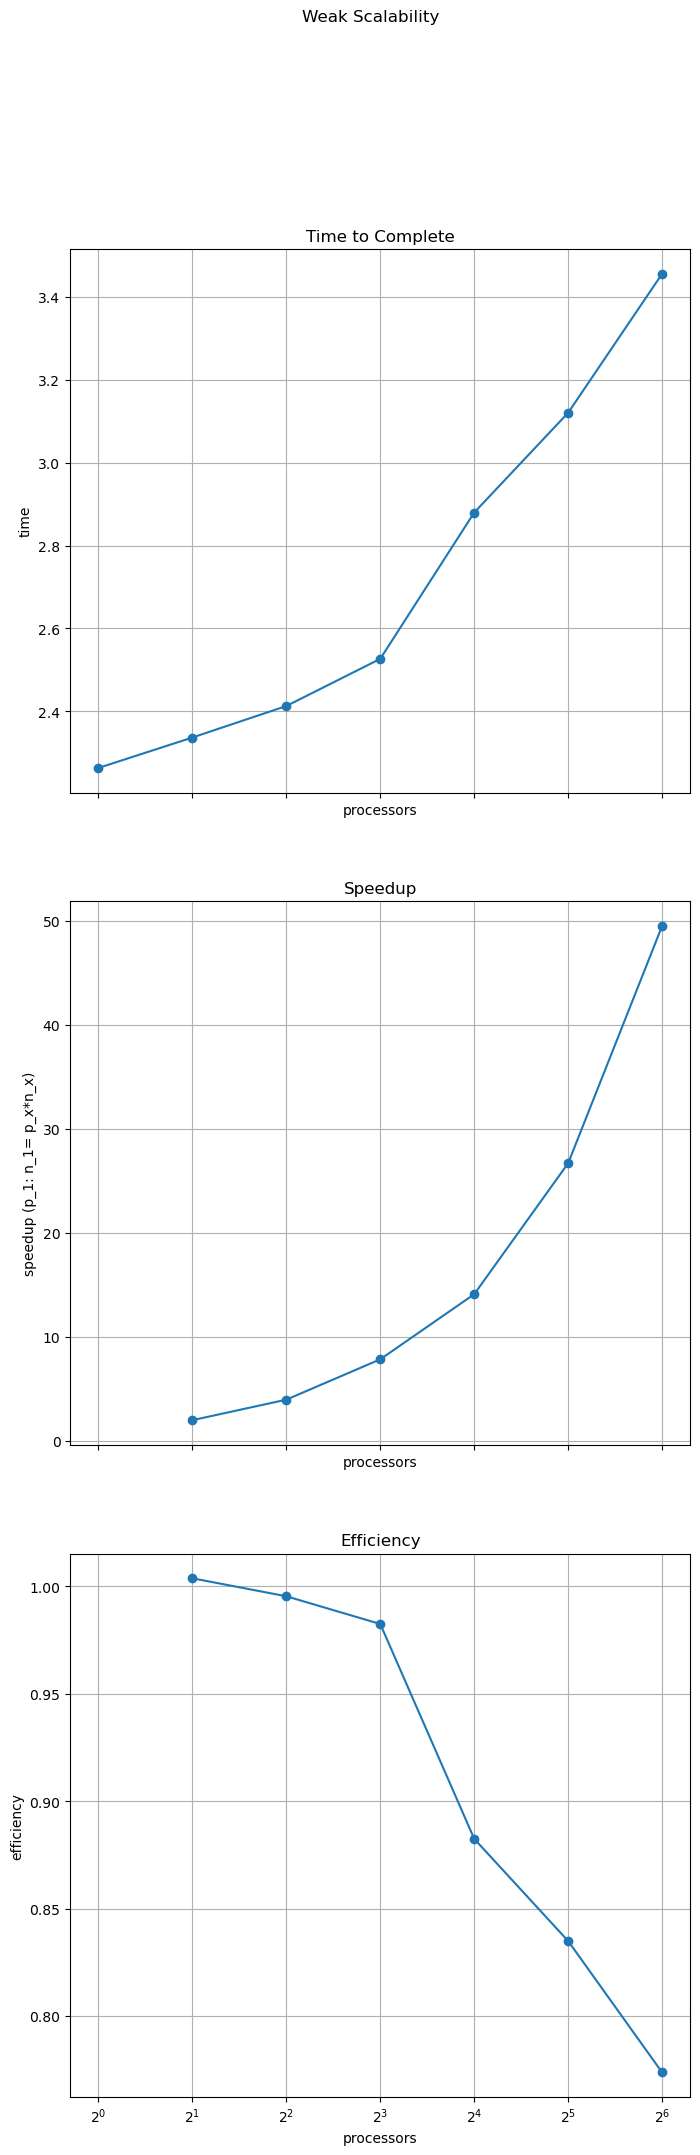

In [30]:
fig, axes = plt.subplots(3,1, figsize=(8, 24), sharex=True)

ps = [1,2,4,8,16,32,64]
time = [D[0][2]]
speedup = []
efficiency = []
i = 2
while i<len(D):
    time.append(D[i][2])
    speedup.append(D[i-1][2]/D[i][2])
    efficiency.append(speedup[-1]/D[i][0])
    i+=2

axes[0].plot(ps, time, marker='o')
axes[0].set_title(f'Time to Complete')
axes[0].set_xlabel(labels[0])
axes[0].set_xscale('log', base=2)   # leaf sizes are powers of 2
axes[0].grid(True)
axes[0].set_ylabel(labels[2])

axes[1].plot(ps[1:], speedup, marker='o')
axes[1].set_title(f'Speedup')
axes[1].set_xlabel(labels[0])
axes[1].set_xscale('log', base=2)   # leaf sizes are powers of 2
axes[1].grid(True)
axes[1].set_ylabel('speedup (p_1: n_1= p_x*n_x)')

axes[2].plot(ps[1:], efficiency, marker='o')
axes[2].set_title(f'Efficiency')
axes[2].set_xlabel(labels[0])
axes[2].set_xscale('log', base=2)   # leaf sizes are powers of 2
axes[2].grid(True)
axes[2].set_ylabel('efficiency')

fig.suptitle('Weak Scalability')
# plt.tight_layout()
plt.savefig('weak.png', dpi=550)
plt.show()

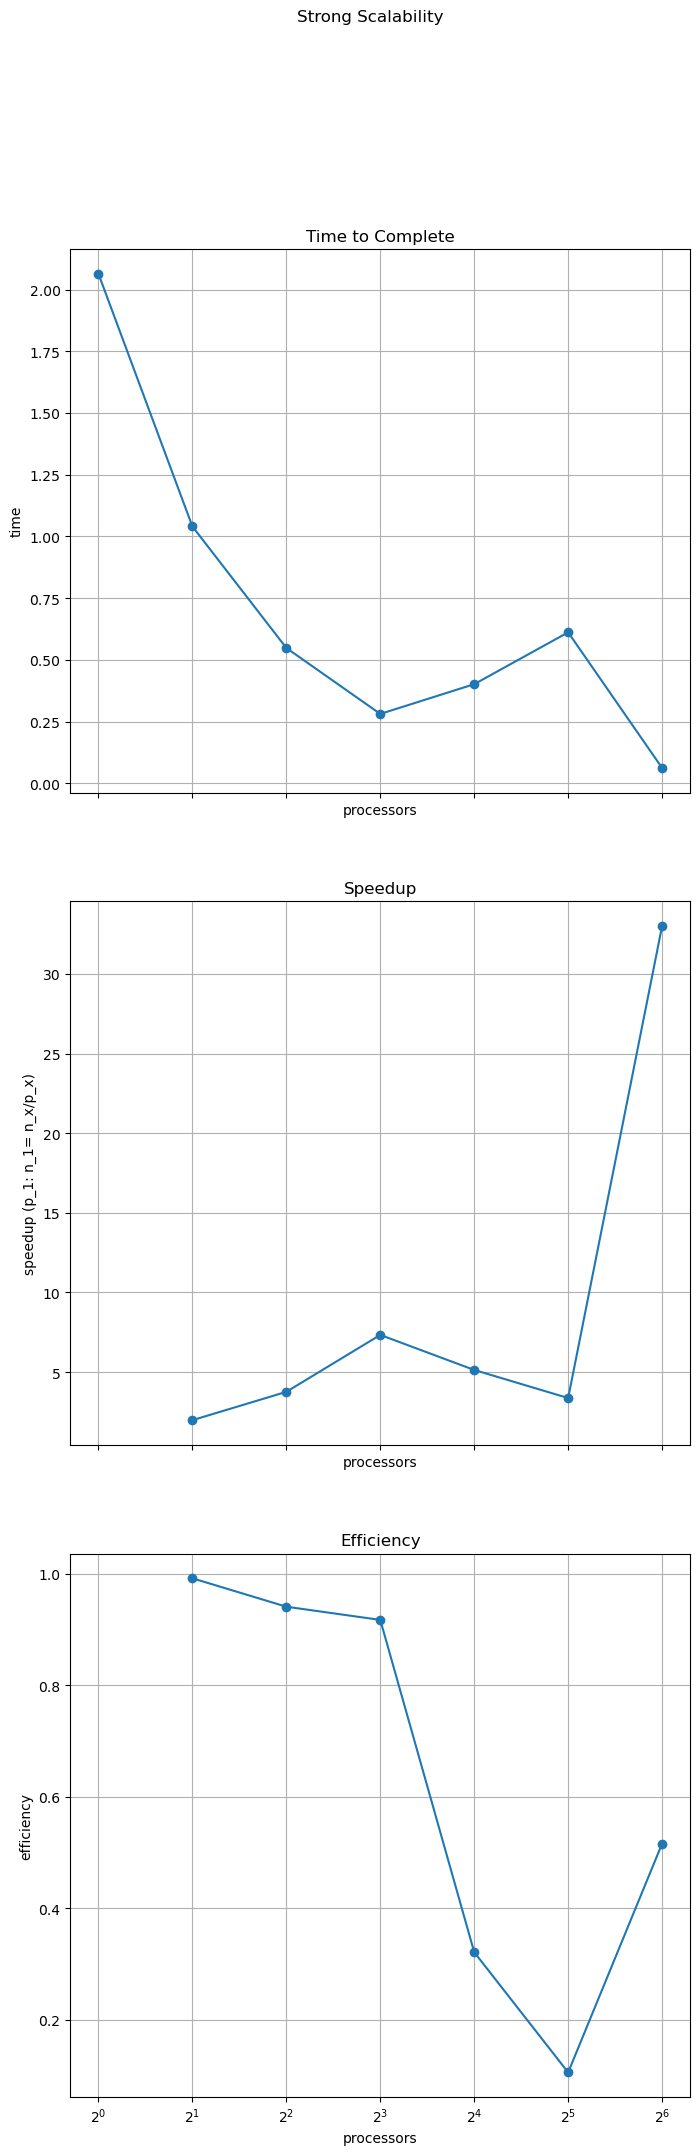

In [31]:
fig, axes = plt.subplots(3,1, figsize=(8, 24), sharex=True)

ps = [1,2,4,8,16,32,64]
time = []
speedup = []
efficiency = []
for row in O:
    if row[0]==1: time.append(row[2]); continue
    time.append(row[2])
    speedup.append(O[0][2]/row[2])
    efficiency.append(speedup[-1]/row[0])

axes[0].plot(ps, time, marker='o')
axes[0].set_title(f'Time to Complete')
axes[0].set_xlabel(labels[0])
axes[0].set_xscale('log', base=2)   # leaf sizes are powers of 2
axes[0].grid(True)
axes[0].set_ylabel(labels[2])

axes[1].plot(ps[1:], speedup, marker='o')
axes[1].set_title(f'Speedup')
axes[1].set_xlabel(labels[0])
axes[1].set_xscale('log', base=2)   # leaf sizes are powers of 2
axes[1].grid(True)
axes[1].set_ylabel('speedup (p_1: n_1= n_x/p_x)')

axes[2].plot(ps[1:], efficiency, marker='o')
axes[2].set_title(f'Efficiency')
axes[2].set_xlabel(labels[0])
axes[2].set_xscale('log', base=2)   # leaf sizes are powers of 2
axes[2].grid(True)
axes[2].set_ylabel('efficiency')

fig.suptitle('Strong Scalability')
# plt.tight_layout()
plt.savefig('strong.png', dpi=550)
plt.show()